<a href="https://colab.research.google.com/github/Rajasri1011-v/task5/blob/main/sri4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

try:
    df = pd.read_csv('heart.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'heart.csv' not found.")
    df = None #Assign None in case of error
except Exception as e:
    print(f"An error occurred: {e}")
    df = None #Assign None in case of error

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


(1025, 14)


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach    

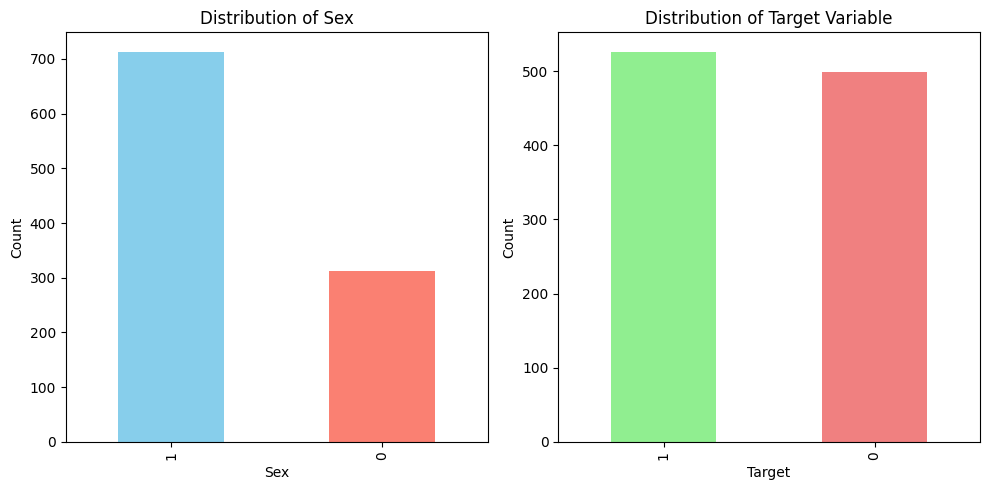

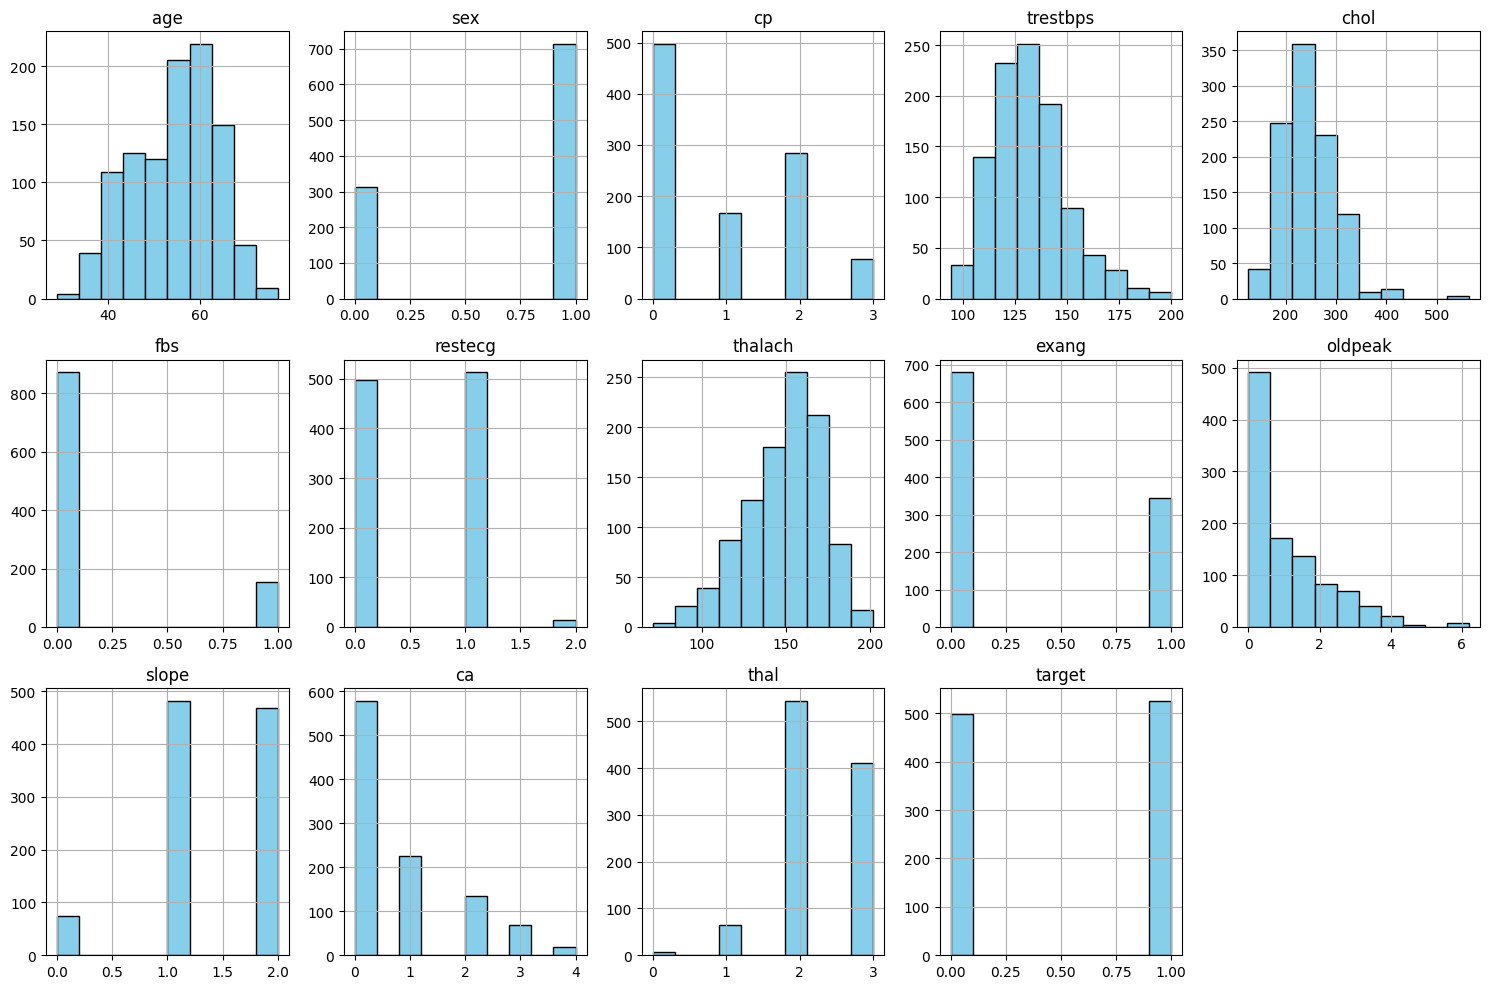

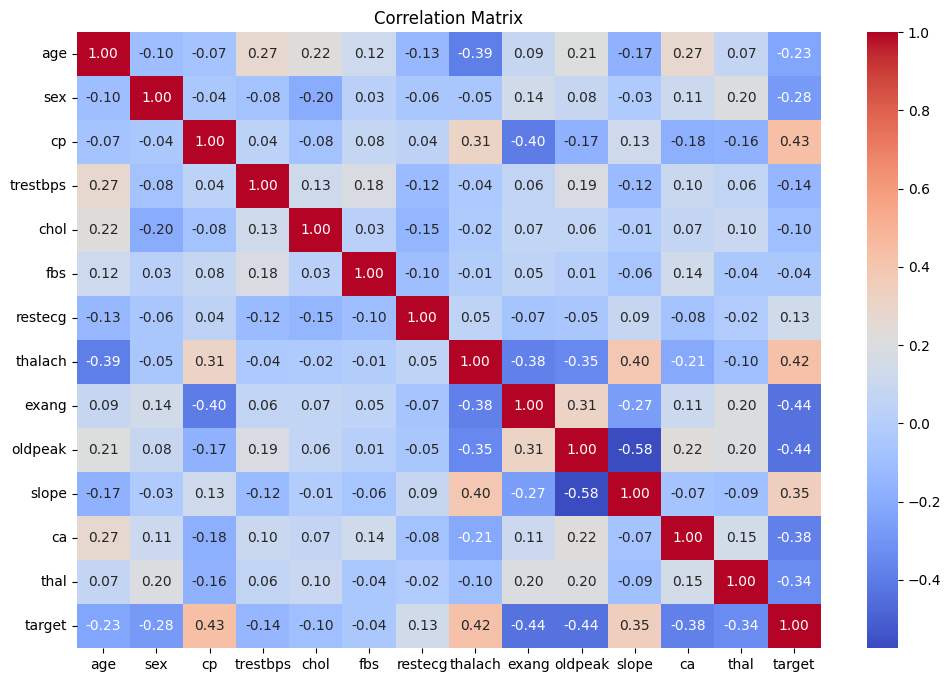

In [2]:
# Check data types
print(df.dtypes)

# Descriptive statistics for numerical features
print(df.describe())

# Missing values
print(df.isnull().sum())

# Analyze categorical features
print(df['sex'].value_counts())
print(df['target'].value_counts())

import matplotlib.pyplot as plt
# Visualize 'sex' and 'target'
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['sex'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['target'].value_counts().plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Visualize numerical features' distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['number']).columns):
    plt.subplot(3, 5, i + 1)
    df[col].hist(bins=10, color='skyblue', edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()


# Correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [3]:
import pandas as pd

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if not categorical_cols:
    categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Create a copy of the DataFrame to store the encoded data
df_encoded = df.copy()

# Apply one-hot encoding or label encoding based on the number of unique categories
for col in categorical_cols:
    if col == 'target':
        continue  # Skip encoding the target variable
    if df[col].nunique() <= 5 : #Using 5 as threshold
        df_encoded = pd.get_dummies(df_encoded, columns=[col], prefix=col, drop_first=True)
    else:
        #Handle cases where label encoding might be more suitable
        print(f"Column '{col}' has many unique values. Consider other encoding methods.")
        #For now, just keep it as is.
        pass


display(df_encoded.head())

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [4]:
from sklearn.model_selection import train_test_split

# Assuming df_encoded is your prepared DataFrame
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


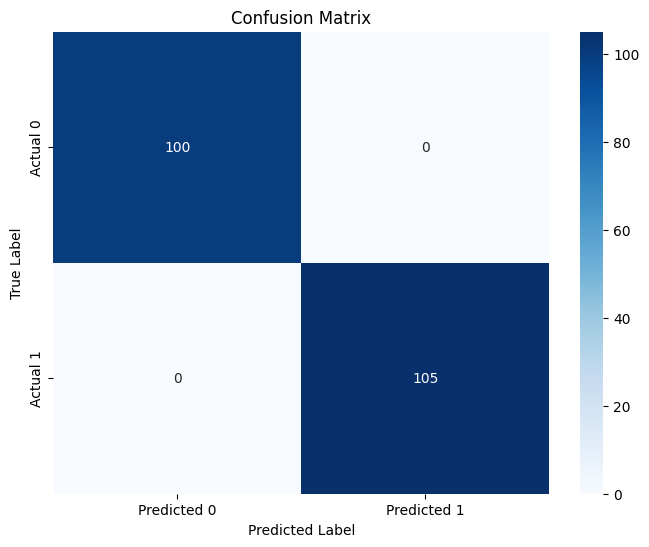

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict the target variable for the test data
y_pred = dt_classifier.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

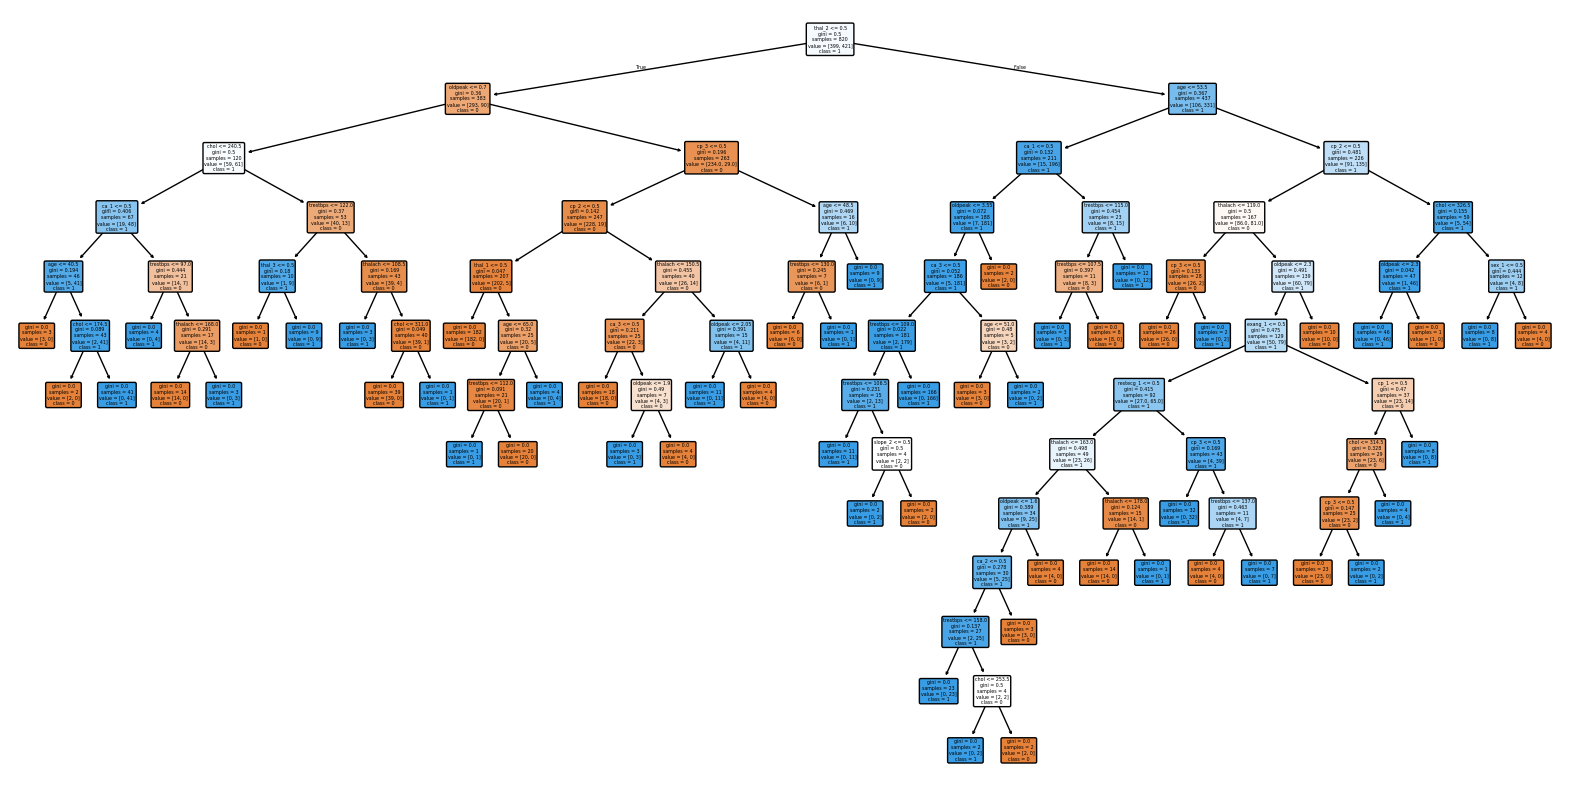

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_classifier, filled=True, rounded=True, class_names=['0','1'], feature_names=X_train.columns)
plt.show()

In [1]:
import pandas as pd

try:
    df = pd.read_csv('heart.csv')
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please ensure the file is in the correct location.")
    df = None  # Set df to None to indicate failure
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

## Data exploration

### Subtask:
Explore the loaded dataset to understand its characteristics.


**Reasoning**:
Examine the shape, descriptive statistics, target variable distribution, missing values, data types, and correlations within the dataframe.



Shape of the DataFrame: (1025, 14)

Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Target Variable Distribution:
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


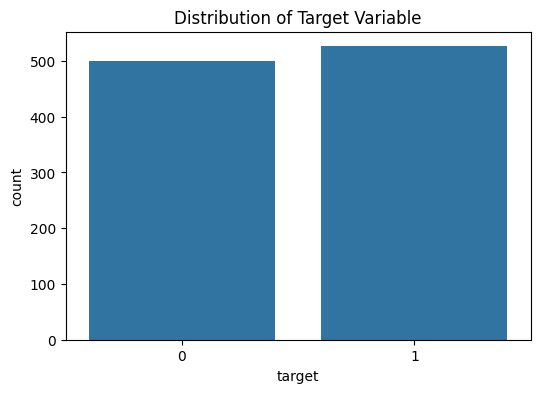


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Correlation Matrix:


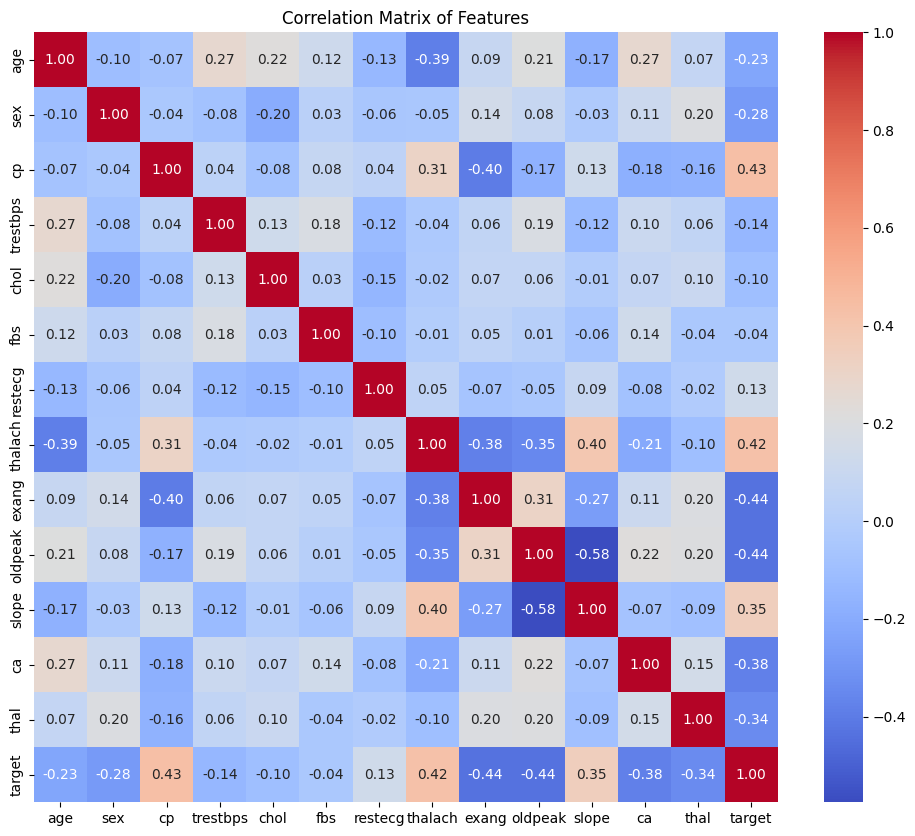

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Examine the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

# 2. Descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

# 3. Analyze the distribution of the target variable
print("\nTarget Variable Distribution:")
print(df['target'].value_counts(normalize=True))
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

# 4. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 5. Investigate data types
print("\nData Types:")
print(df.dtypes)

# 6. Explore correlations between features
print("\nCorrelation Matrix:")
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# 7. Document your observations (This will be done in the finish_task command)

## Data preparation

### Subtask:
Prepare the data for model training by handling potential data type conversions and scaling numerical features.


**Reasoning**:
Convert categorical features to numerical representations using one-hot encoding and scale numerical features using standardization.  The 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', and 'thal' columns appear to be categorical and should be one-hot encoded.  The remaining columns are numerical and should be standardized.  The 'target' column is the target variable and should not be scaled.



In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np

# Identify categorical features
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Apply one-hot encoding to categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate encoded features with the original DataFrame
df_encoded = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)

# Separate features and target variable
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Scale numerical features using standardization
scaler = StandardScaler()
numerical_cols = X.columns.difference(encoder.get_feature_names_out(categorical_cols))
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Concatenate scaled features and target variable back into a single DataFrame
df_scaled = pd.concat([X, y], axis=1)

display(df_scaled.head())

,age,trestbps,chol,thalach,oldpeak,sex_0,sex_1,cp_0,cp_1,cp_2,...,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3,target
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,0.834359,0.364875,0.930822,-1.874977,0.705408,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


In [4]:
from sklearn.model_selection import train_test_split

# Split data into features (X) and target (y)
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the DecisionTreeClassifier without depth restrictions
dt_unrestricted = DecisionTreeClassifier()

# Fit the classifier to the training data
dt_unrestricted.fit(X_train, y_train)

DecisionTreeClassifier()

,Metric,Training,Testing
0,Accuracy,1.0,0.985366
1,Precision,1.0,1.000000
2,Recall,1.0,0.971429
3,F1-score,1.0,0.985507
4,AUC-ROC,1.0,0.985714


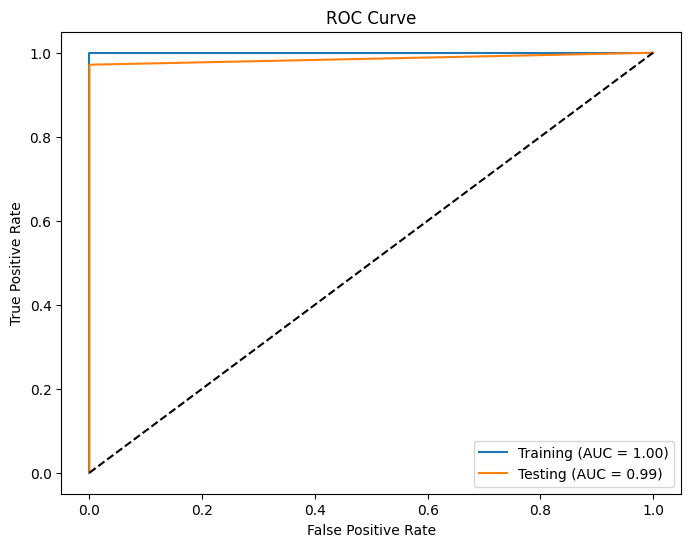

from matplotlib import pyplot as plt
metrics_df['Testing'].plot(kind='hist', bins=20, title='Testing')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
metrics_df.groupby('Metric').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Training']
  ys = series['Testing']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = metrics_df.sort_values('Training', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Metric')):
  _plot_series(series, series_name, i)
  fig.legend(title='Metric', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Training')
_ = plt.ylabel('Testing')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Training']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Training'}, axis=1)
              .sort_values('Training', ascending=True))
  xs = counted['Training']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = metrics_df.sort_values('Training', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Metric')):
  _plot_series(series, series_name, i)
  fig.legend(title='Metric', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Training')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
metrics_df['Testing'].plot(kind='line', figsize=(8, 4), title='Testing')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(metrics_df['Metric'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(metrics_df, x='Testing', y='Metric', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict on training and testing sets
y_train_pred = dt_unrestricted.predict(X_train)
y_test_pred = dt_unrestricted.predict(X_test)

# Probability predictions for ROC AUC
y_train_proba = dt_unrestricted.predict_proba(X_train)[:, 1]
y_test_proba = dt_unrestricted.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
def evaluate_model(y_true, y_pred, y_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    return accuracy, precision, recall, f1, roc_auc

train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba)

# Print or display the metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC'],
    'Training': train_metrics,
    'Testing': test_metrics
})
display(metrics_df)

# ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {roc_auc_score(y_train, y_train_proba):.2f})')
plt.plot(fpr_test, tpr_test, label=f'Testing (AUC = {roc_auc_score(y_test, y_test_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

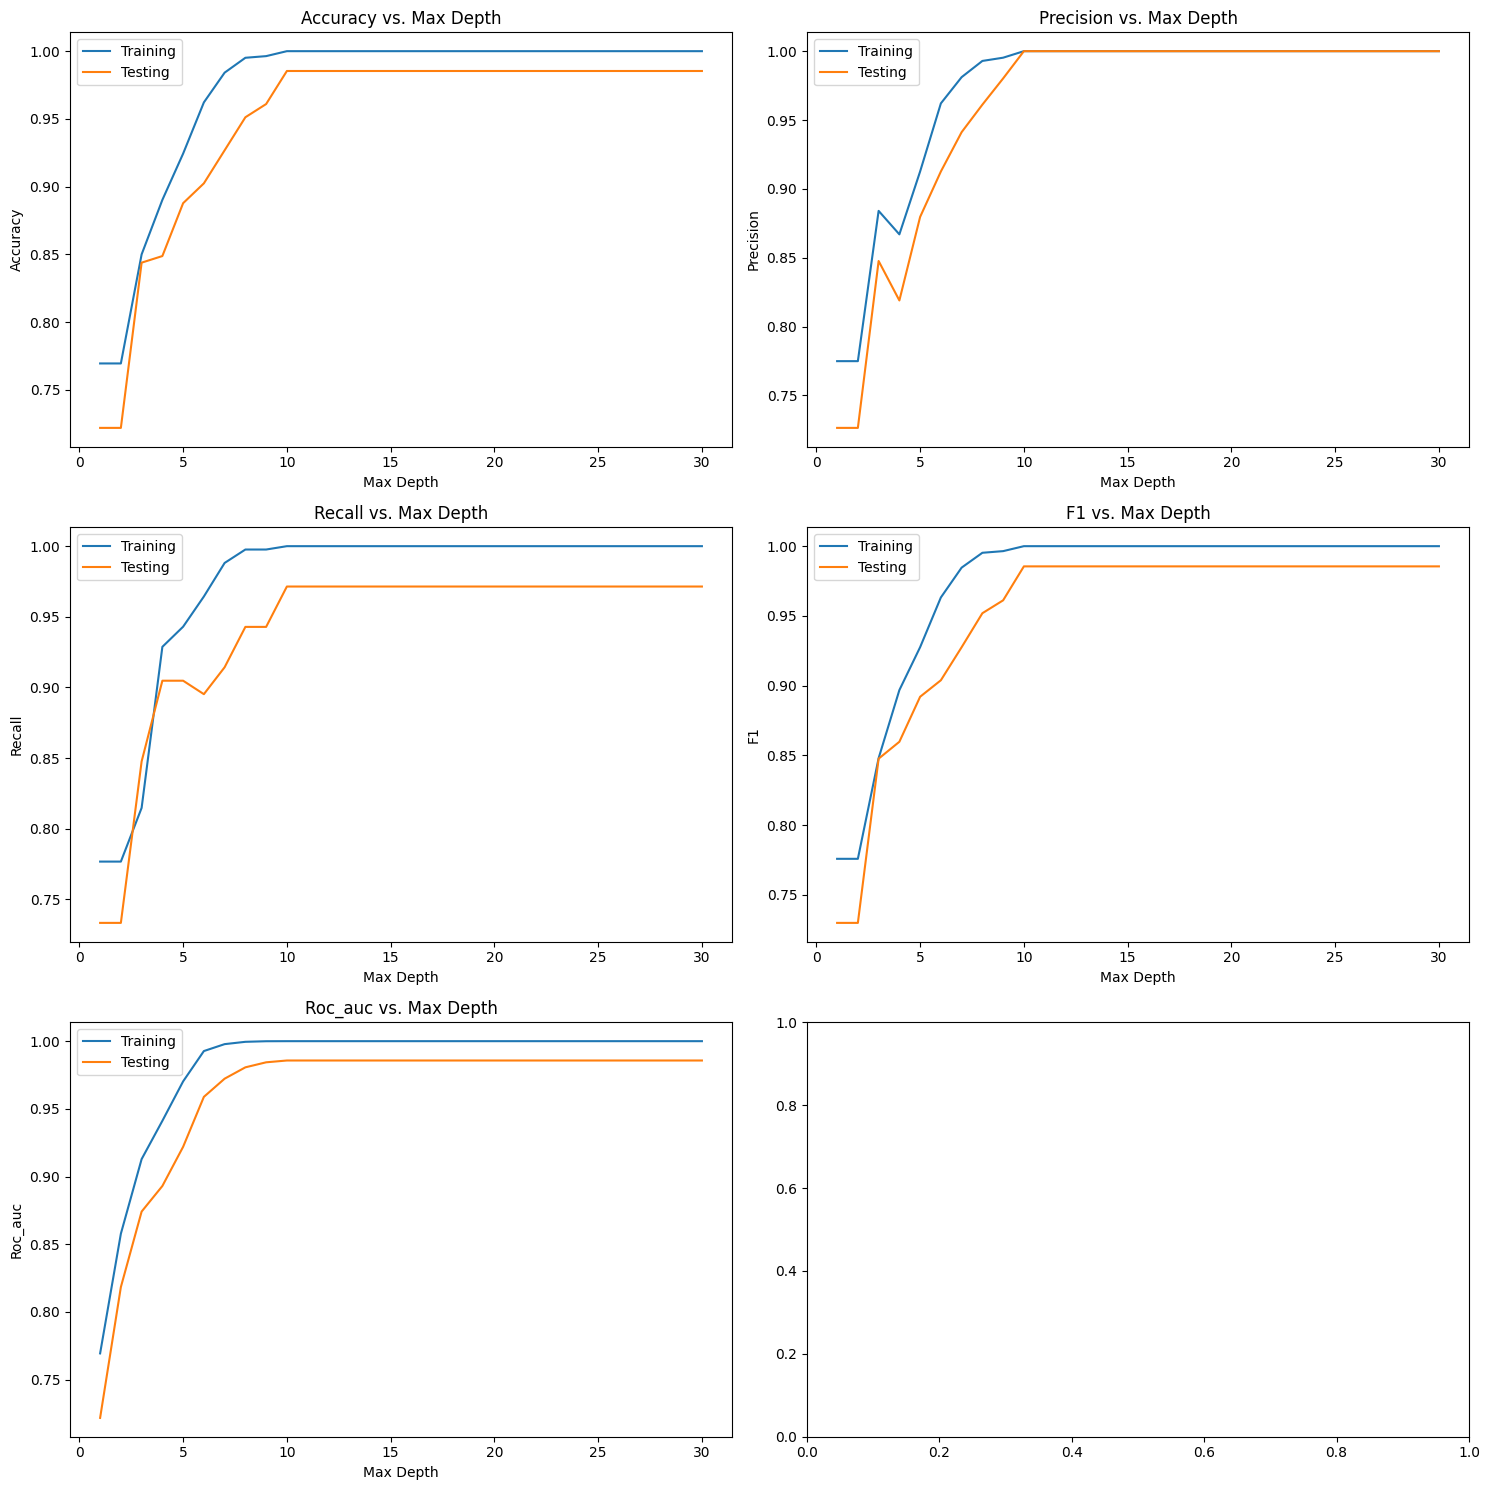

,max_depth,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,1,0.769512,0.721951,0.774882,0.726415,0.776722,0.733333,0.775801,0.729858,0.769313,0.721667
1,2,0.769512,0.721951,0.774882,0.726415,0.776722,0.733333,0.775801,0.729858,0.857756,0.818333
2,3,0.850000,0.843902,0.884021,0.847619,0.814727,0.847619,0.847960,0.847619,0.912852,0.874095
3,4,0.890244,0.848780,0.866962,0.818966,0.928741,0.904762,0.896789,0.859729,0.941138,0.893000
4,5,0.924390,0.887805,0.912644,0.879630,0.942993,0.904762,0.927570,0.892019,0.970291,0.921952
5,6,0.962195,0.902439,0.962085,0.912621,0.964371,0.895238,0.963227,0.903846,0.992696,0.958857
6,7,0.984146,0.926829,0.981132,0.941176,0.988124,0.914286,0.984615,0.927536,0.997806,0.972286
7,8,0.995122,0.951220,0.992908,0.961165,0.997625,0.942857,0.995261,0.951923,0.999524,0.980667
8,9,0.996341,0.960976,0.995261,0.980198,0.997625,0.942857,0.996441,0.961165,0.999952,0.984381
9,10,1.000000,0.985366,1.000000,1.000000,1.000000,0.971429,1.000000,0.985507,1.000000,0.985714


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a list of max_depth values
max_depths = list(range(1, 31))
results = []

# 2. Iterate through max_depth values and evaluate the model
for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    y_train_proba = dt.predict_proba(X_train)[:, 1]
    y_test_proba = dt.predict_proba(X_test)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    test_roc_auc = roc_auc_score(y_test, y_test_proba)

    results.append([depth, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall, train_f1, test_f1, train_roc_auc, test_roc_auc])

# 3. Create a DataFrame to store results
columns = ['max_depth', 'train_accuracy', 'test_accuracy', 'train_precision', 'test_precision', 'train_recall', 'test_recall', 'train_f1', 'test_f1', 'train_roc_auc', 'test_roc_auc']
results_df = pd.DataFrame(results, columns=columns)

# 4. Visualize the performance metrics
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    axes[row, col].plot(results_df['max_depth'], results_df[f'train_{metric}'], label='Training')
    axes[row, col].plot(results_df['max_depth'], results_df[f'test_{metric}'], label='Testing')
    axes[row, col].set_xlabel('Max Depth')
    axes[row, col].set_ylabel(metric.capitalize())
    axes[row, col].set_title(f'{metric.capitalize()} vs. Max Depth')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

display(results_df)

In [8]:
# Find the optimal max_depth
optimal_depth = results_df['max_depth'][ (results_df['test_accuracy'] == results_df['test_accuracy'].max()) & (results_df['test_precision'] == results_df['test_precision'].max())]
if len(optimal_depth) > 1 :
    optimal_depth = results_df['max_depth'][(results_df['test_recall'] == results_df['test_recall'].max())]

if len(optimal_depth) > 1 :
    optimal_depth = results_df['max_depth'][(results_df['test_f1'] == results_df['test_f1'].max())]

if len(optimal_depth) > 1 :
    optimal_depth = results_df['max_depth'][(results_df['test_roc_auc'] == results_df['test_roc_auc'].max())]

optimal_depth = optimal_depth.iloc[0]
print(f"Optimal max_depth: {optimal_depth}")


# Get the corresponding test performance metrics
optimal_metrics = results_df[results_df['max_depth'] == optimal_depth][['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']]
print(f"\nTest performance metrics at optimal max_depth:\n{optimal_metrics}")

Optimal max_depth: 10

Test performance metrics at optimal max_depth:
   test_accuracy  test_precision  test_recall   test_f1  test_roc_auc
9       0.985366             1.0     0.971429  0.985507      0.985714


In [1]:
import pandas as pd

try:
    df = pd.read_csv('heart.csv')
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: 'heart.csv' not found.")
    df = None  # Assign None to df in case of error
except Exception as e:
    print(f"An error occurred: {e}")
    df = None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

Shape of the DataFrame: (1025, 14)

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Descriptive Statistics:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   20

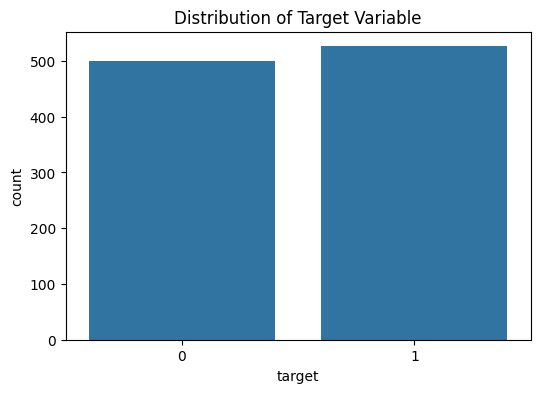


Categorical Feature Value Counts:

sex:
sex
1    713
0    312
Name: count, dtype: int64

cp:
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

fbs:
fbs
0    872
1    153
Name: count, dtype: int64

restecg:
restecg
1    513
0    497
2     15
Name: count, dtype: int64

exang:
exang
0    680
1    345
Name: count, dtype: int64

slope:
slope
1    482
2    469
0     74
Name: count, dtype: int64

ca:
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

thal:
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64


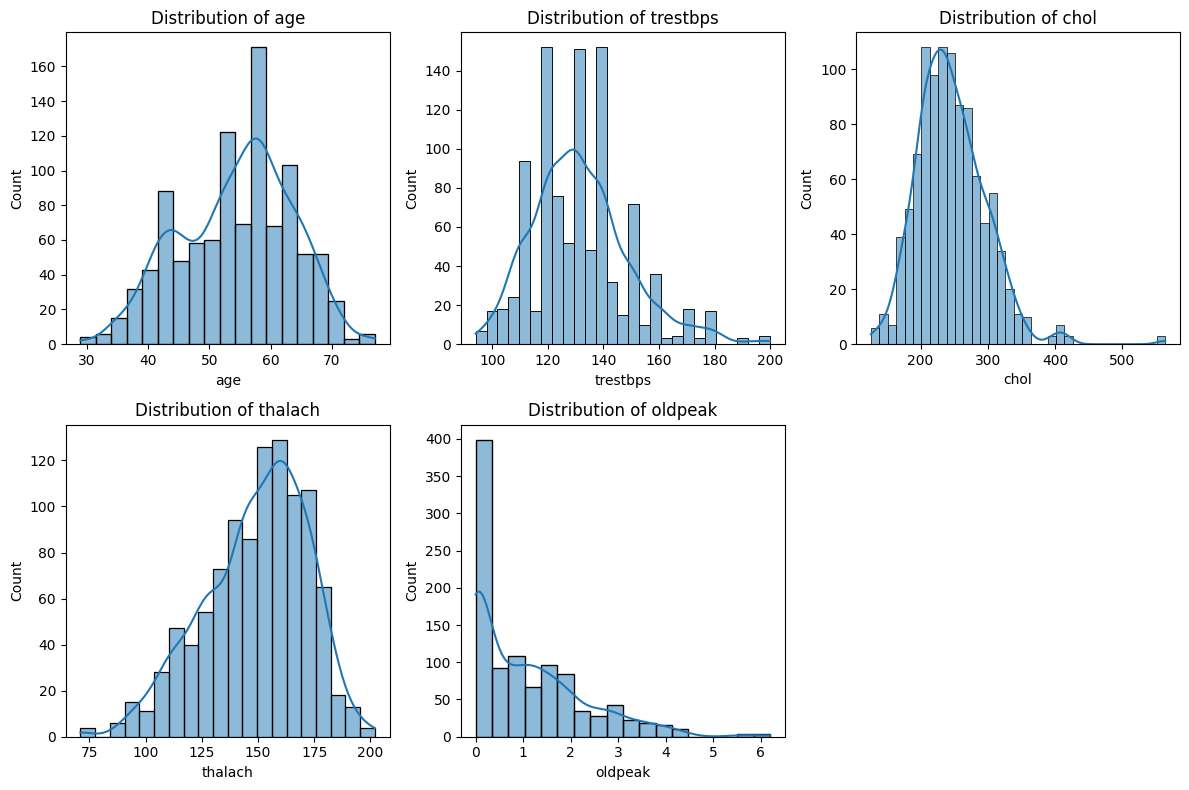

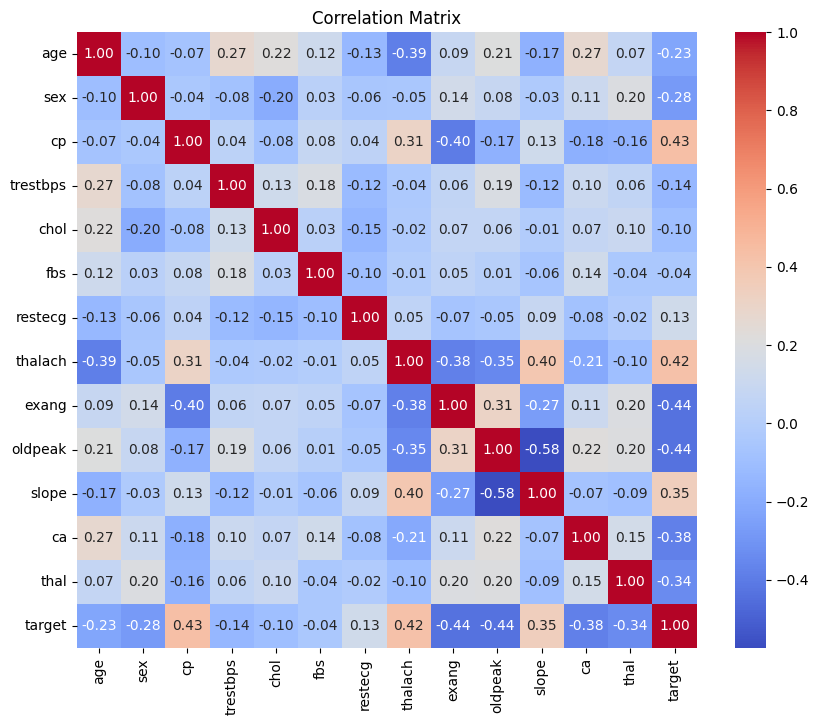

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Examine the shape of the DataFrame
print(f"Shape of the DataFrame: {df.shape}")

# 2. Check data types
print("\nData Types:")
print(df.dtypes)

# 3. Descriptive statistics of numerical features
print("\nDescriptive Statistics:")
print(df.describe())

# 4. Analyze the distribution of the target variable
print("\nTarget Variable Distribution:")
print(df['target'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

# 5. Explore categorical features
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print("\nCategorical Feature Value Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# 6. Visualize distributions of key numerical features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 7. Calculate and visualize correlation
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 8. Document your observations (will be done in the finish_task command)

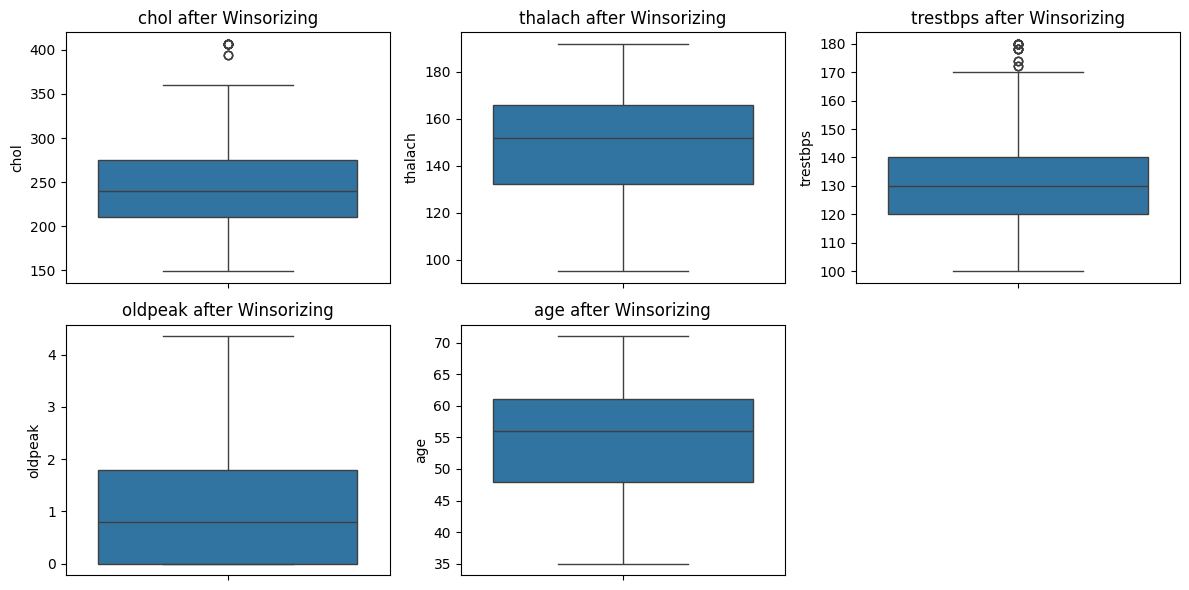

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical features to examine
numerical_features = ['chol', 'thalach', 'trestbps', 'oldpeak', 'age']

# Calculate the 1st and 99th percentiles for each numerical feature
for col in numerical_features:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

# Re-examine the distributions using box plots
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col} after Winsorizing')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Identify categorical features
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Identify numerical features
numerical_cols = [col for col in df_encoded.columns if col not in categorical_cols and col != 'target']

# Scale numerical features
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

display(df_encoded.head())

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.271893,-0.383511,-0.687305,0.835160,-0.053654,0,0.661504,-0.441179,-0.619085,-0.284998,...,-0.712287,-0.942158,1.088807,-0.531840,2.578615,-0.268655,-0.133697,-0.258065,-1.063474,1.224745
1,-0.159654,0.496168,-0.871138,0.257985,1.792047,0,0.661504,-0.441179,-0.619085,-0.284998,...,1.403928,-0.942158,-0.918436,-0.531840,-0.387805,-0.268655,-0.133697,-0.258065,-1.063474,1.224745
2,1.748417,0.789394,-1.463488,-1.073956,1.352595,0,0.661504,-0.441179,-0.619085,-0.284998,...,1.403928,-0.942158,-0.918436,-0.531840,-0.387805,-0.268655,-0.133697,-0.258065,-1.063474,1.224745
3,0.738262,0.965330,-0.871138,0.524373,-0.932559,0,0.661504,-0.441179,-0.619085,-0.284998,...,-0.712287,-0.942158,1.088807,1.880265,-0.387805,-0.268655,-0.133697,-0.258065,-1.063474,1.224745
4,0.850501,0.378877,0.987615,-1.917519,0.737361,0,-1.511706,-0.441179,-0.619085,-0.284998,...,-0.712287,1.061393,-0.918436,-0.531840,-0.387805,3.722240,-0.133697,-0.258065,0.940314,-0.816497


In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print shapes of the resulting sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(820, 22) (205, 22) (820,) (205,)


In [6]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Train the classifier
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the corresponding best score
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Store the best estimator
best_rf_model = grid_search.best_estimator_

Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best score: 0.9817073170731707


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC: 1.0


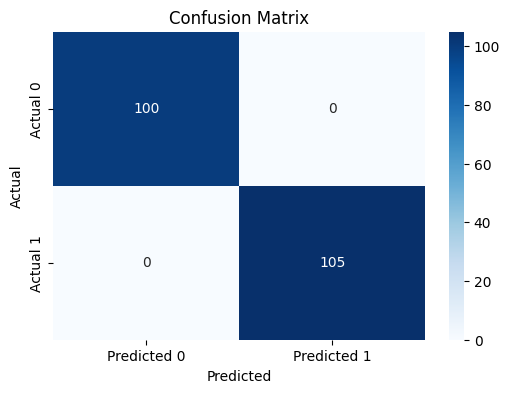

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC: {auc}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

In [1]:
import pandas as pd

try:
    df = pd.read_csv('heart.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'heart.csv' not found.")
    df = None #added this to avoid error
except Exception as e:
    print(f"An error occurred: {e}")
    df = None #added this to avoid error

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


(1025, 14)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

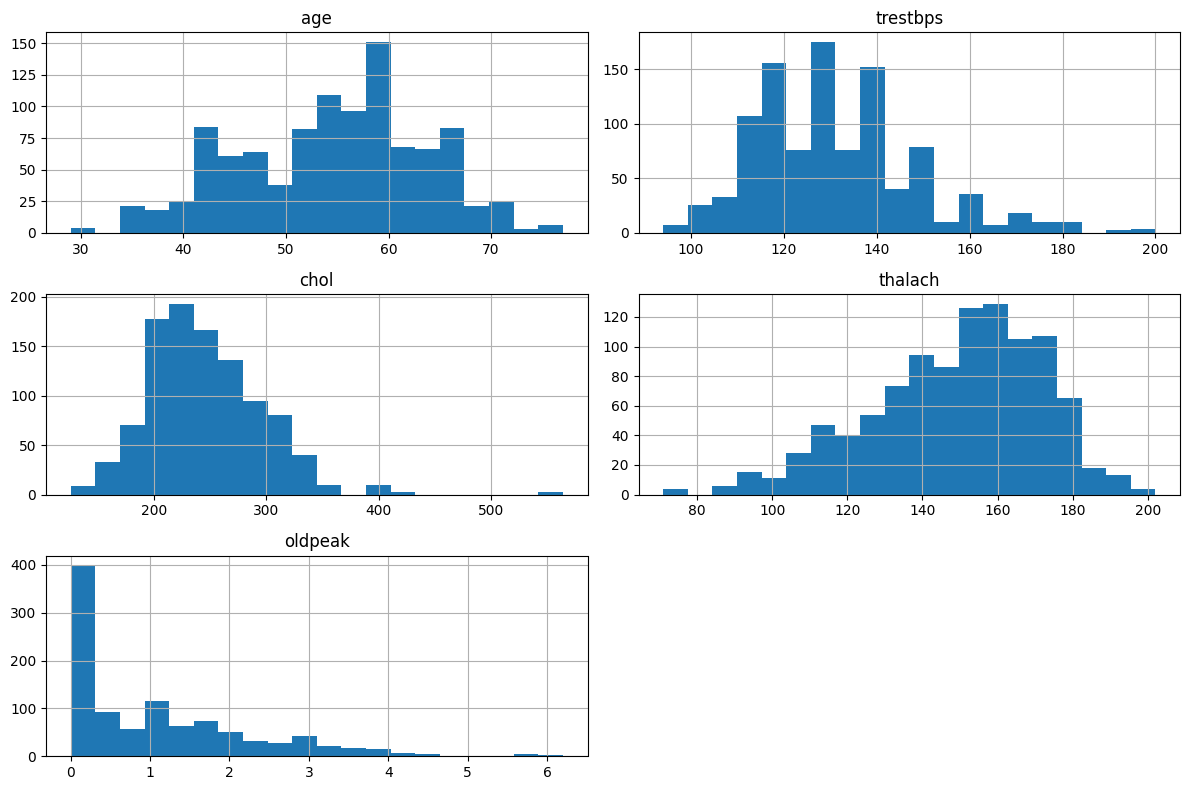

Value counts for sex:
sex
1    713
0    312
Name: count, dtype: int64

Value counts for cp:
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

Value counts for fbs:
fbs
0    872
1    153
Name: count, dtype: int64

Value counts for restecg:
restecg
1    513
0    497
2     15
Name: count, dtype: int64

Value counts for exang:
exang
0    680
1    345
Name: count, dtype: int64

Value counts for slope:
slope
1    482
2    469
0     74
Name: count, dtype: int64

Value counts for ca:
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

Value counts for thal:
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64

Value counts for target:
target
1    526
0    499
Name: count, dtype: int64



In [2]:
# Examine Data Types and Summary Statistics
print(df.info())
print(df.describe())

# Check for Missing Values
print(df.isnull().sum())

# Analyze Data Distributions (Histograms for numerical features)
import matplotlib.pyplot as plt
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numerical_features].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# Analyze Data Distributions (Value counts for categorical features)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in categorical_features:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

**Reasoning**:
I need to explore the relationships between variables, including correlations between numerical features and relationships between numerical and categorical features.  I will create a correlation matrix and box plots to achieve this.



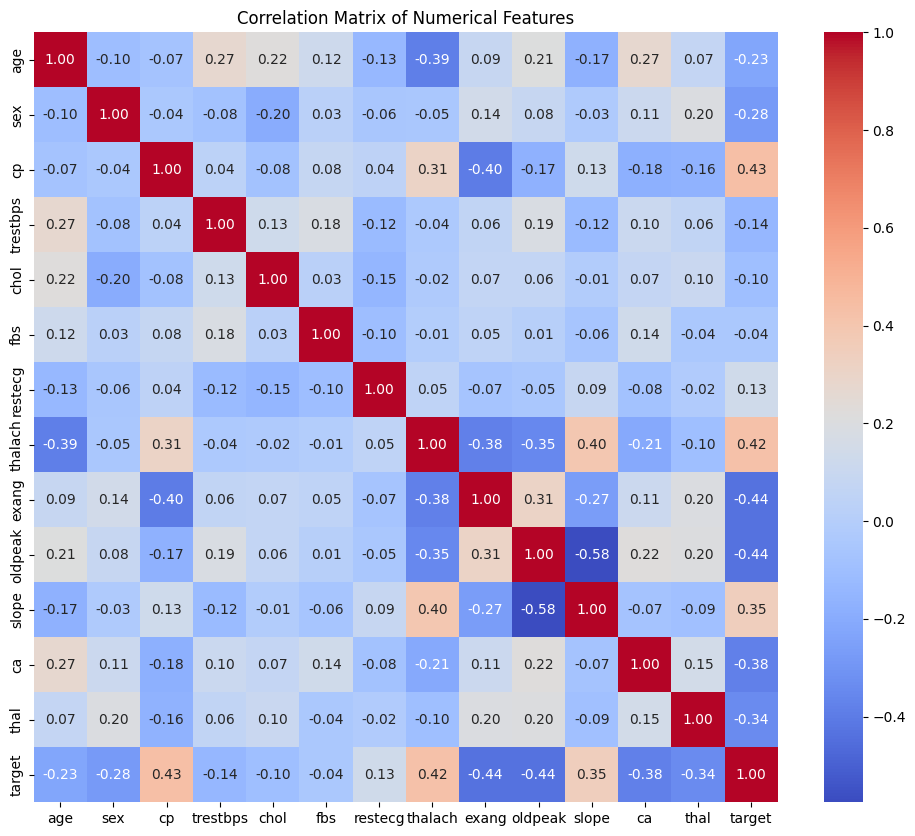

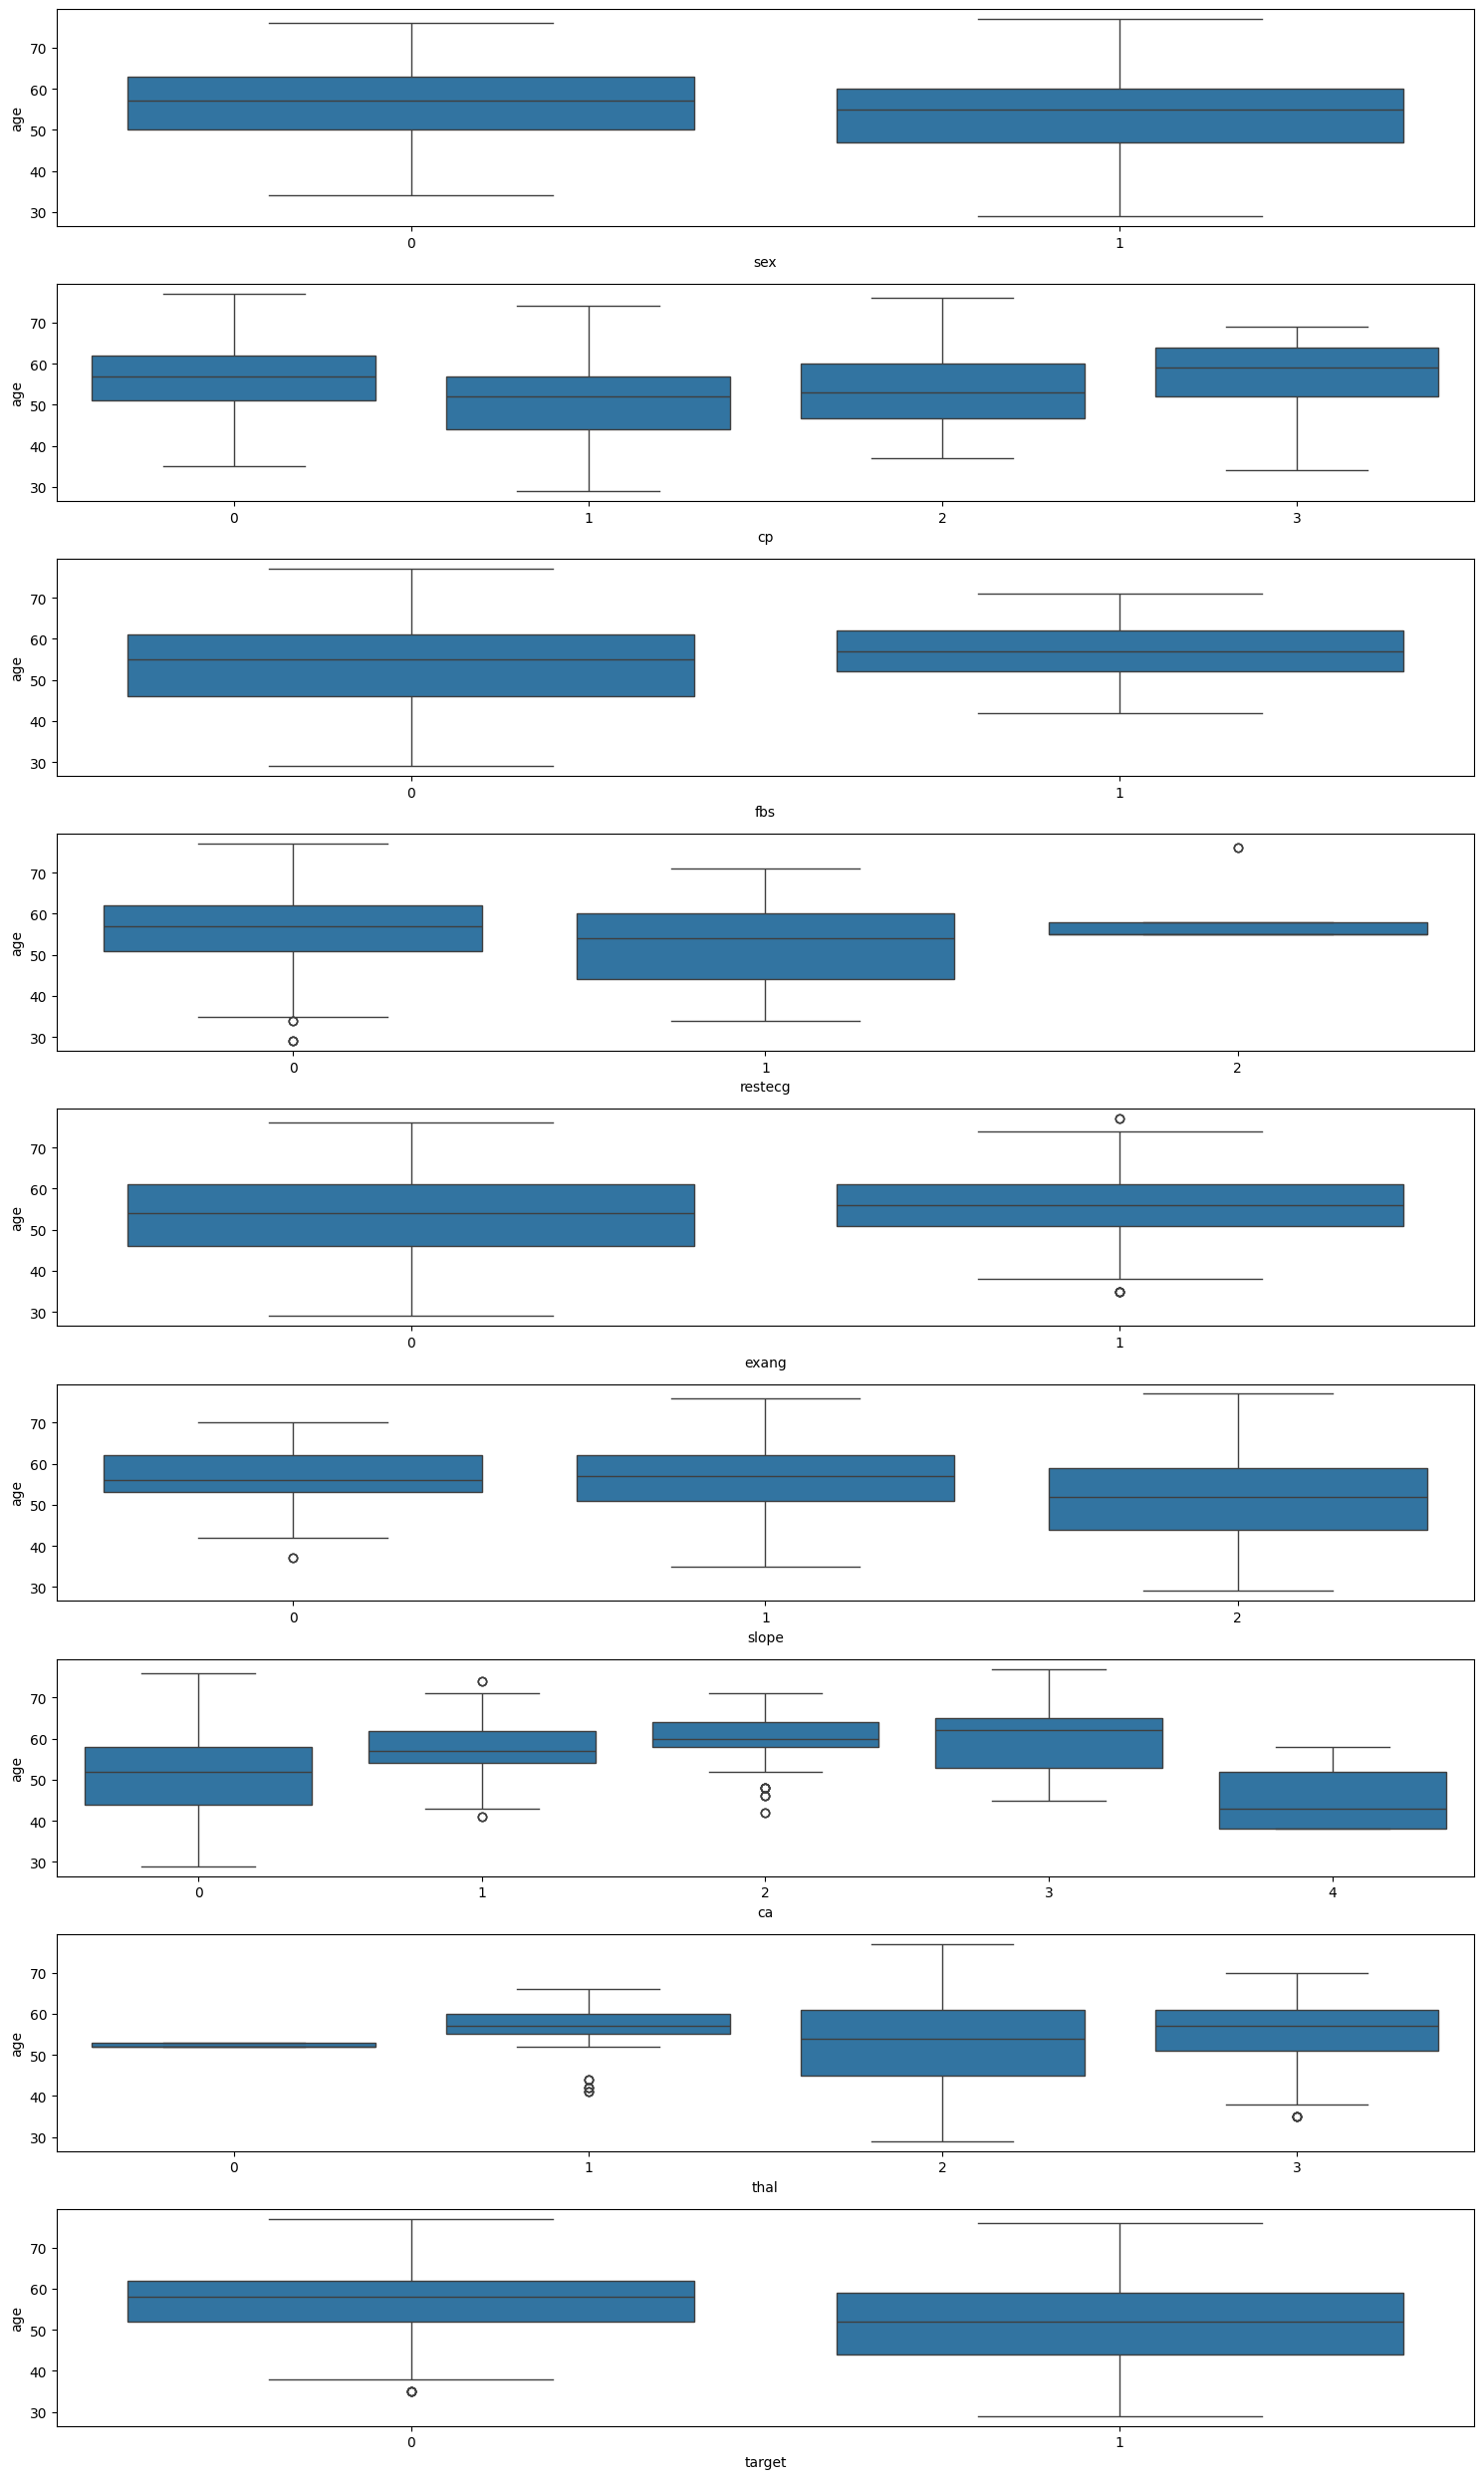

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explore Relationships between Variables (Correlation Matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Explore Relationships between Numerical and Categorical Features (Box Plots)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 25))
for i, col in enumerate(categorical_features):
    plt.subplot(len(categorical_features), 1, i + 1)
    sns.boxplot(x=col, y='age', data=df)
plt.tight_layout()
plt.show()



In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Handle Missing Values (already checked in the data exploration)
# The data exploration step showed no missing values, so this step is skipped.

# 2. Encode Categorical Features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
target = 'target'

# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Pass through the target column without transformation
)


# 3. Separate Features and Target
X = df.drop(columns=[target])
y = df[target]


# 4. Scale Numerical Features and Encode Categorical Features
X_encoded = preprocessor.fit_transform(X)

# Convert the encoded features back into a DataFrame (optional, but helpful for inspection)
feature_names = list(preprocessor.named_transformers_['num'].get_feature_names_out(numerical_features))
feature_names.extend(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
X_encoded = pd.DataFrame(X_encoded, columns=feature_names)
display(X_encoded.head())

,age,trestbps,chol,thalach,oldpeak,sex_0,sex_1,cp_0,cp_1,cp_2,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.834359,0.364875,0.930822,-1.874977,0.705408,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_encoded, y)

RandomForestClassifier(random_state=42)

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Predict the target variable
y_pred = rf_model.predict(X_encoded)

# Calculate evaluation metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='weighted')
recall = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')
auc = roc_auc_score(y, rf_model.predict_proba(X_encoded)[:, 1])

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC: {auc}")

# Print the classification report
print("\nClassification Report:\n", classification_report(y, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       499
           1       1.00      1.00      1.00       526

    accuracy                           1.00      1025
   macro avg       1.00      1.00      1.00      1025
weighted avg       1.00      1.00      1.00      1025



In [7]:
import pandas as pd

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a pandas Series for better visualization
feature_importance_series = pd.Series(feature_importances, index=X_encoded.columns)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Display the top 10 most important features
display(sorted_feature_importances.head(10))

,0
thalach,0.095706
oldpeak,0.094874
cp_0,0.090458
thal_2,0.086333
ca_0,0.073266
age,0.071804
chol,0.068599
thal_3,0.066020
trestbps,0.058207
exang_1,0.038693


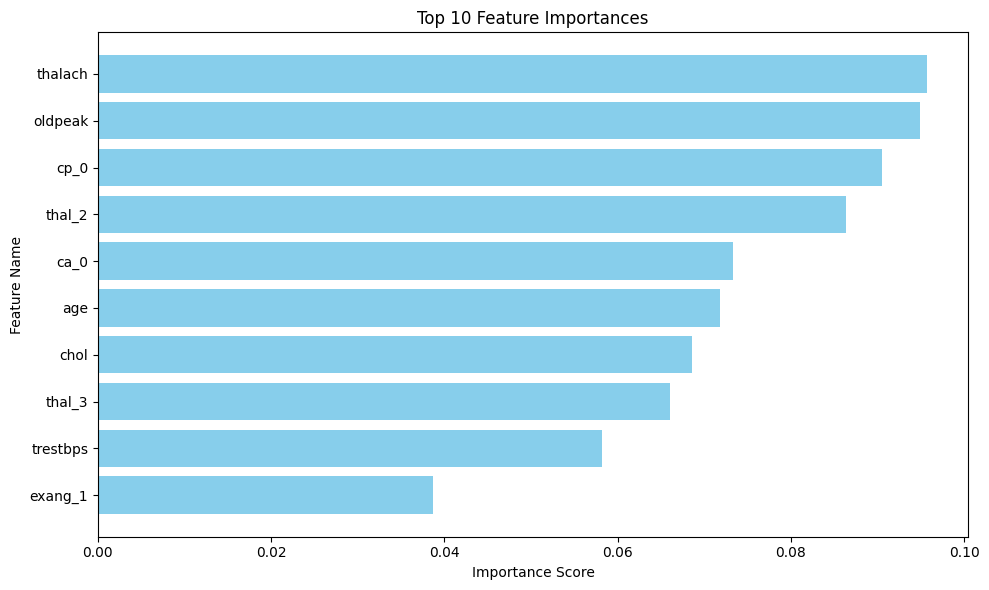

In [8]:
import matplotlib.pyplot as plt

# Assuming 'sorted_feature_importances' from the previous step is available

# Select the top 10 features
top_10_features = sorted_feature_importances.head(10)

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
plt.barh(top_10_features.index, top_10_features.values, color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

try:
    df = pd.read_csv('heart.csv')
    display(df.head())
    print(df.shape)
    df.info()
except FileNotFoundError:
    print("Error: 'heart.csv' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


target
1    526
0    499
Name: count, dtype: int64


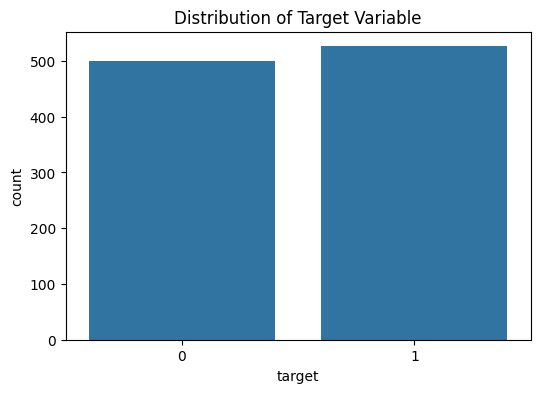

Percentage of each class:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Descriptive Statistics:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000

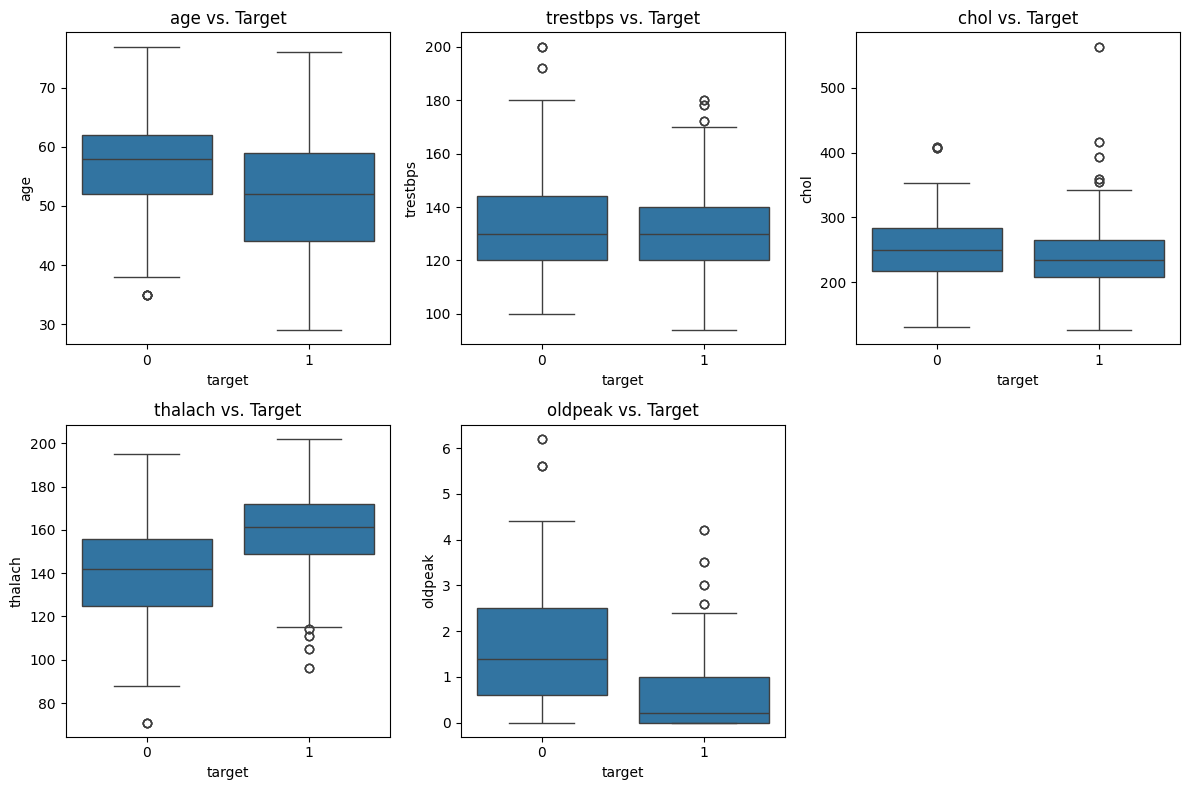

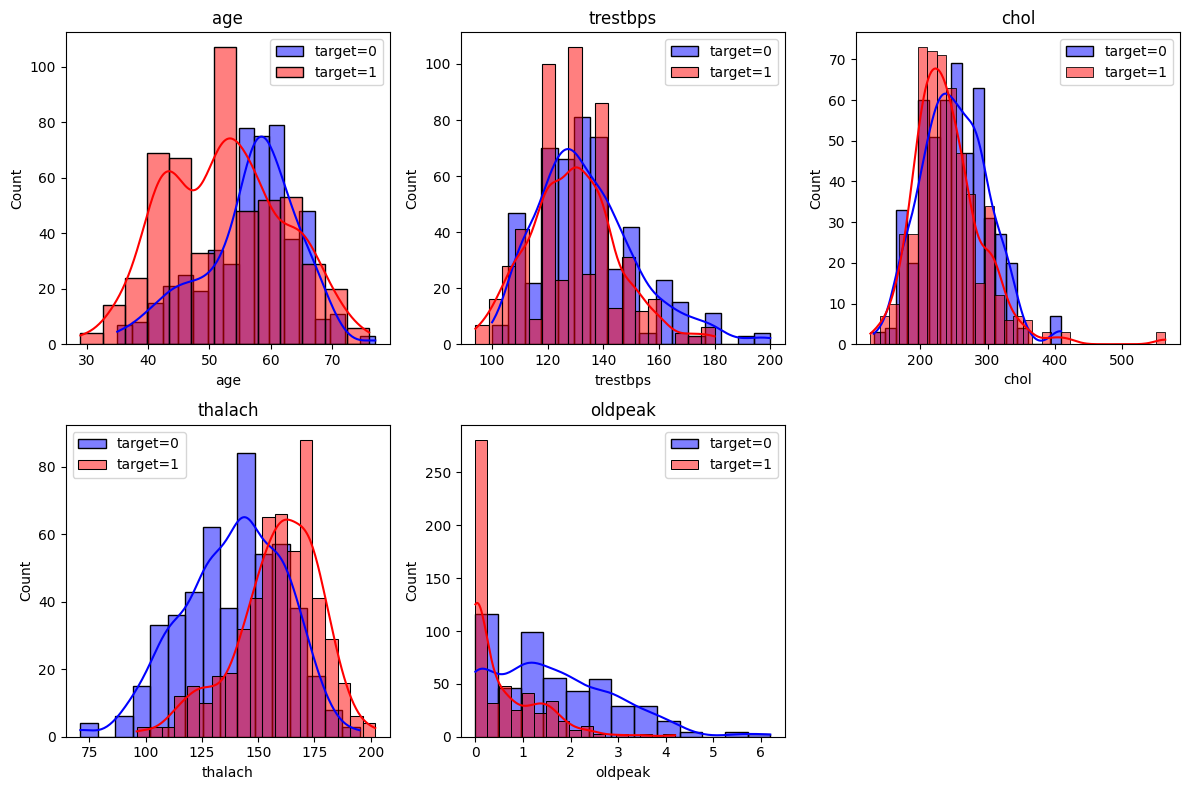

Summary of Findings: 
The target variable shows some imbalance.
No missing values were detected.
The descriptive statistics provide summary measures of the numerical features.
The box plots and histograms show the distribution of numerical features for each target group.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze the distribution of the target variable
print(df['target'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.show()
target_percentage = df['target'].value_counts(normalize=True) * 100
print(f"Percentage of each class:\n{target_percentage}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Calculate descriptive statistics
print(f"\nDescriptive Statistics:\n{df.describe()}")

# Explore relationships between numerical features and the target variable
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='target', y=feature, data=df)
    plt.title(f'{feature} vs. Target')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[df['target']==0][feature], color='blue', label='target=0', kde=True)
    sns.histplot(df[df['target']==1][feature], color='red', label='target=1', kde=True)
    plt.title(feature)
    plt.legend()
plt.tight_layout()
plt.show()

print("Summary of Findings: ")
print("The target variable shows some imbalance.")
print("No missing values were detected.")
print("The descriptive statistics provide summary measures of the numerical features.")
print("The box plots and histograms show the distribution of numerical features for each target group.")


In [3]:
from sklearn.preprocessing import StandardScaler

# Select numerical features to scale (excluding the target variable)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
df_scaled = df.copy()  # Create a copy to avoid modifying the original DataFrame
df_scaled[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display the first few rows of the scaled DataFrame
display(df_scaled.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.268437,1,0,-0.377636,-0.659332,0,1,0.821321,0,-0.060888,2,2,3,0
1,-0.158157,1,0,0.479107,-0.833861,1,0,0.255968,1,1.727137,0,0,3,0
2,1.716595,1,0,0.764688,-1.396233,0,1,-1.048692,1,1.301417,0,0,3,0
3,0.724079,1,0,0.936037,-0.833861,0,1,0.516900,0,-0.912329,2,1,3,0
4,0.834359,0,0,0.364875,0.930822,1,1,-1.874977,0,0.705408,1,3,2,0


from matplotlib import pyplot as plt
_df_0['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['sex'].plot(kind='hist', bins=20, title='sex')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['trestbps'].plot(kind='hist', bins=20, title='trestbps')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['chol'].plot(kind='hist', bins=20, title='chol')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['cp']
  ys = series['chol']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('cp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('cp')
_ = plt.ylabel('chol')

from matplotlib import pyplot as plt
_df_12['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['sex'].plot(kind='line', figsize=(8, 4), title='sex')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['trestbps'].plot(kind='line', figsize=(8, 4), title='trestbps')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['chol'].plot(kind='line', figsize=(8, 4), title='chol')
plt.gca().spines[['top', 'right']].set_visible(False)

In [4]:
# Split the scaled data into features (X) and target variable (y)
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000, solver='liblinear')

# Fit the model to the data
logreg_model.fit(X, y)

LogisticRegression(max_iter=1000, solver='liblinear')

In [6]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

# Perform 5-fold cross-validation
accuracy_scores = cross_val_score(logreg_model, X, y, cv=5, scoring='accuracy')

# Predict probabilities using cross-validation
y_pred_prob = cross_val_predict(logreg_model, X, y, cv=5, method='predict_proba')[:, 1]
y_pred = cross_val_predict(logreg_model, X, y, cv=5)


# Calculate metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_prob)

# Print the results
print(f"Average Accuracy: {accuracy_scores.mean()}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {roc_auc}")
print(classification_report(y, y_pred))

Average Accuracy: 0.8487804878048781
Accuracy: 0.848780487804878
Precision: 0.8271604938271605
Recall: 0.8916349809885932
F1-score: 0.8581884720951509
AUC-ROC: 0.9157249860938607
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       499
           1       0.83      0.89      0.86       526

    accuracy                           0.85      1025
   macro avg       0.85      0.85      0.85      1025
weighted avg       0.85      0.85      0.85      1025

